In [54]:
import pandas as pd

df = pd.read_csv('../data/sample_labels.csv')
print(df.shape)
df.head()

(5606, 11)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [55]:
import itertools
print("Desease categories:")
deseases = sorted(set(itertools.chain.from_iterable(df["Finding Labels"].str.split("|"))))
deseases

Desease categories:


['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [56]:
# Create one-hot encoded disease columns for each disease
disease_columns = sorted(set(itertools.chain.from_iterable(df["Finding Labels"].str.split("|"))))
for disease in disease_columns:
    df[disease] = df["Finding Labels"].str.split("|").apply(lambda x: int(disease in x))

df.drop(columns=['Finding Labels'], inplace=True)

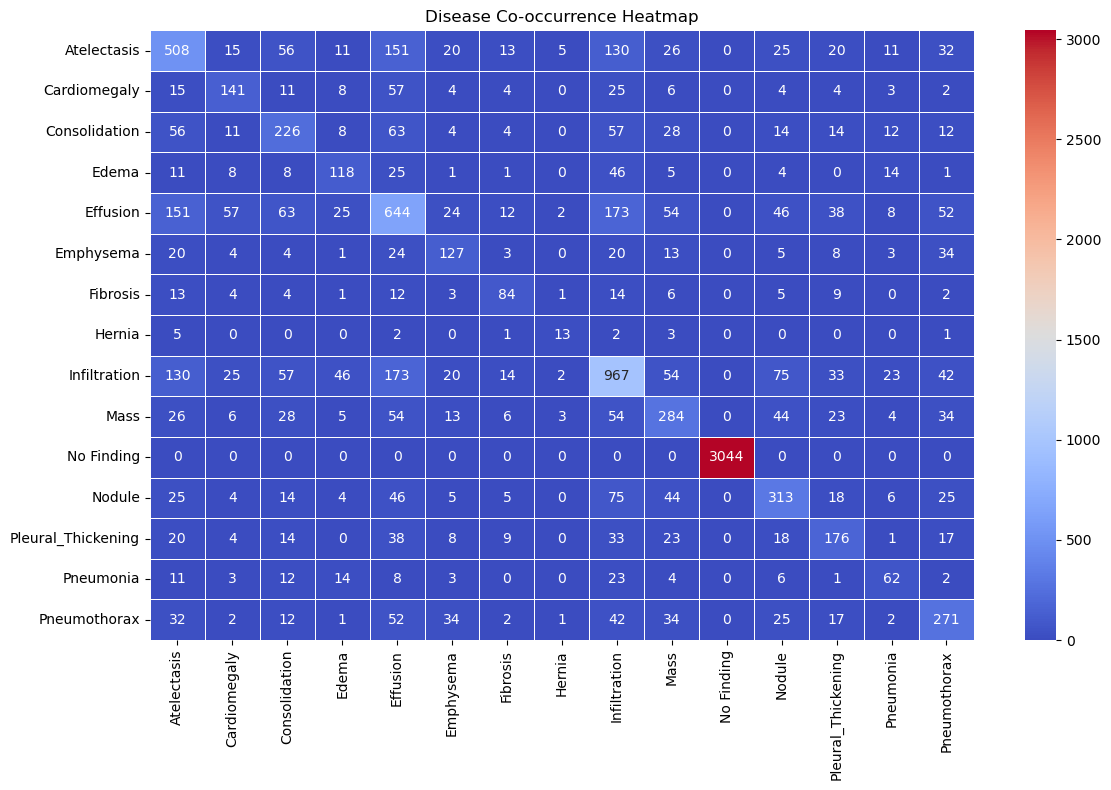

In [65]:
# Visualize the real disease co-occurrence matrix in the actual dataframe

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Disease columns (these were computed earlier and dropped "Finding Labels")
disease_cols = [col for col in df.columns if col not in [
    'Image Index', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender',
    'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 
    'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y'
]]

# Compute the co-occurrence matrix: how often each pair of diseases occurs together
co_matrix = np.zeros((len(disease_cols), len(disease_cols)), dtype=int)
for i, d1 in enumerate(disease_cols):
    for j, d2 in enumerate(disease_cols):
        co_matrix[i, j] = ((df[d1] == 1) & (df[d2] == 1)).sum()

plt.figure(figsize=(12, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', xticklabels=disease_cols, yticklabels=disease_cols, cmap="coolwarm", linewidths=0.5)
plt.title("Disease Co-occurrence Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [66]:
# Visualize the disease co-occurrence as a chord diagram using the computed co_matrix

import plotly.graph_objects as go

def plot_chord(co_matrix, disease_cols):
    n = len(disease_cols)
    # Normalize for display (sum of each row)
    matrix_norm = co_matrix / np.clip(co_matrix.sum(axis=1, keepdims=True), 1, None)
    # Use only upper triangle for non-redundant links
    sources, targets, values = [], [], []
    for i in range(n):
        for j in range(n):
            if i != j and co_matrix[i, j] > 0:
                sources.append(i)
                targets.append(j)
                values.append(co_matrix[i, j])

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=10,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=disease_cols,
            color="blue"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color="rgba(31, 119, 180, 0.3)"
        )
    )])
    fig.update_layout(title_text="Disease Co-occurrence Sankey Diagram (Chord-like)", font_size=12, width=1000, height=500)
    fig.show()

plot_chord(co_matrix, disease_cols)

In [ ]:
!pip install chord

from chord import Chord

matrix = [
    [0, 5, 6, 4, 7, 4],
    [5, 0, 5, 4, 6, 5],
    [6, 5, 0, 4, 5, 5],
    [4, 4, 4, 0, 5, 5],
    [7, 6, 5, 5, 0, 4],
    [4, 5, 5, 5, 4, 0],
]


names = ["Action", "Adventure", "Comedy", "Drama", "Fantasy", "Thriller"]

print(matrix)

Chord(matrix, names).to_html("../../static/interactiveCharts/chord-diagram-chord-library.html") 

[[0, 5, 6, 4, 7, 4], [5, 0, 5, 4, 6, 5], [6, 5, 0, 4, 5, 5], [4, 4, 4, 0, 5, 5], [7, 6, 5, 5, 0, 4], [4, 5, 5, 5, 4, 0]]


Exception: {'reason': 'Authentication failed. Please check your license details or get one from https://plotapi.com.'}

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
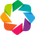

:Chord   [start,end]   (Value)

In [44]:
import pandas as pd
import holoviews as hv
from holoviews import opts

# 1. Enable the Bokeh backend for interactivity
hv.extension('bokeh')

# 2. Define the 15 Labels
labels = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# 3. Short Mock Data (Co-occurrence pairs: Source, Target, Frequency)
# These represent clinical "clusters" for a realistic graph
data = [
    # Heart Failure Cluster
    ('Cardiomegaly', 'Effusion', 25),
    ('Cardiomegaly', 'Edema', 18),
    ('Edema', 'Effusion', 20),
    
    # Infection Cluster
    ('Infiltration', 'Atelectasis', 20),
    ('Infiltration', 'Pneumonia', 15),
    ('Consolidation', 'Pneumonia', 12),
    ('Consolidation', 'Effusion', 14),
    
    # Lung Mass Cluster
    ('Mass', 'Nodule', 22),
    ('Mass', 'Infiltration', 8),
    ('Nodule', 'Effusion', 7),
    
    # Chronic/Other
    ('Emphysema', 'Pneumothorax', 15),
    ('Fibrosis', 'Pleural_Thickening', 8),
    ('Effusion', 'Pleural_Thickening', 12),
    ('Atelectasis', 'Pneumothorax', 5)
]

# 4. Create the Chord object
# We provide the links (data) and the explicit list of nodes (labels)
chord = hv.Chord(data, vdims='Value')

# 5. Apply Styling
chord.opts(
    opts.Chord(
        cmap='Category20',           # Uses a 20-color palette for 15 labels
        edge_color=hv.Cycle('Category20'), 
        node_color=hv.Cycle('Category20'),
        labels='index',              # Show label names on the outer ring
        label_text_font_size='9pt',
        width=700, 
        height=700,
        title="Chest X-ray Pathology Co-occurrence",
        toolbar='above'             # Allows zooming and saving
    )
)

# To display in a Jupyter Notebook:
chord

In [ ]:
# Define the nodes (optional, but helps with ordering)
nodes = hv.Dataset(pd.DataFrame(labels, columns=['index']), 'index')

chord = hv.Chord((df_links, nodes)).select(value=(5, None)) # Filter out very weak connections

chord.opts(
    opts.Chord(
        cmap='Category20', 
        edge_color=hv.Cycle('Category20'), 
        node_color=hv.Cycle('Category20'),
        labels='index', 
        label_text_font_size='8pt',
        width=600, 
        height=600,
        title="Medical Finding Co-occurrence"
    )
)

In [39]:
df.head()

,Image Index,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000013_005.png,5,13,060Y,M,AP,3056,2544,0.139,0.139,...,1,0,0,1,0,0,0,1,0,1
1,00000013_026.png,26,13,057Y,M,AP,2500,2048,0.168,0.168,...,1,0,0,0,0,0,0,0,0,0
2,00000017_001.png,1,17,077Y,M,AP,2500,2048,0.168,0.168,...,0,0,0,0,0,1,0,0,0,0
3,00000030_001.png,1,30,079Y,M,PA,2992,2991,0.143,0.143,...,0,0,0,0,0,0,0,0,0,0
4,00000032_001.png,1,32,055Y,F,AP,2500,2048,0.168,0.168,...,0,0,0,0,0,0,0,0,0,0


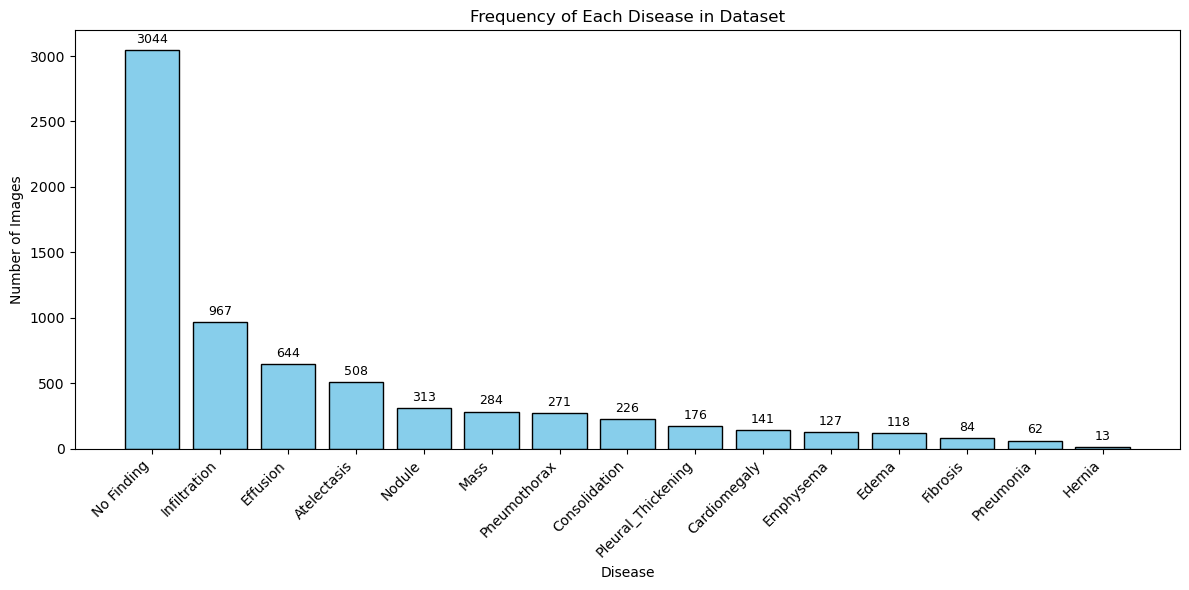

In [40]:
import matplotlib.pyplot as plt

# Visualize disease frequency (bar chart)
disease_counts = df[disease_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, color='skyblue', edgecolor='k')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Disease')
plt.ylabel('Number of Images')
plt.title('Frequency of Each Disease in Dataset')
plt.tight_layout()

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
plt.show()


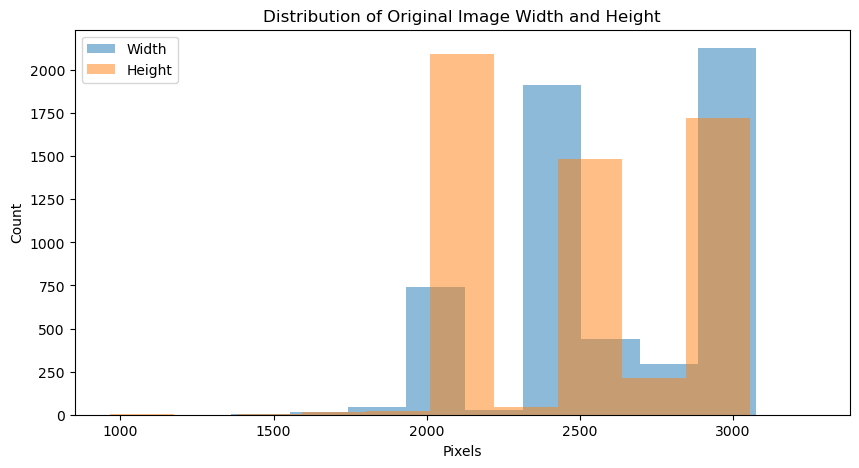

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['OriginalImageWidth'], alpha=0.5, label="Width")
plt.hist(df['OriginalImageHeight' if 'OriginalImageHeight' in df.columns else '\tOriginalImageHeight'], alpha=0.5, label="Height")
plt.legend()
plt.title("Distribution of Original Image Width and Height")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()

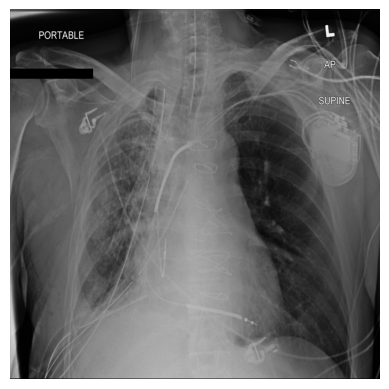

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def visualise_image(image):
    plt.imshow(image)
    plt.axis('off')
    plt.show()

img_path = './../data/sample/images/00000013_005.png'

image = Image.open(img_path).convert("RGB")
visualise_image(image)


       
#image = transforms.ToTensor()(image)

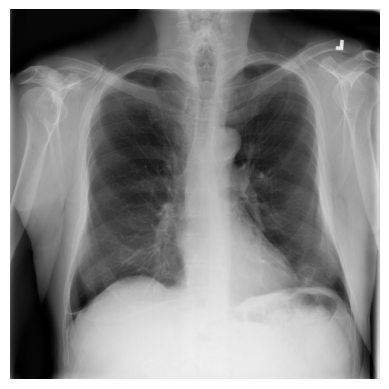

In [31]:
img_path = './../data/sample/images/00000030_001.png'

image = Image.open(img_path).convert("RGB")
visualise_image(image)